# Week 2：我怎么一步步手写 Transformer

- 作者：王雷
- 日期：2026-07-17
- 适用周次：Week 2
- 分类：06-nlp（相关基础：05-pytorch）
- 关键词：Embedding、位置编码、Q/K/V、多头注意力、Mask、Encoder、Decoder

这份 Notebook 不是把一个完整模型直接贴出来，而是按我当时的学习顺序，把 Transformer 拆成几个能单独理解的小组件。从最开始弄清出 `(batch, time, d_model)` 里的三个数字分别在做什么，后来才一步步走到 Encoder、Decoder 和 mask。

代码已经把当时的实现修正为可以分享的版本，但保留了“先遇到问题、再解释为什么”的痕迹。Notebook 使用目录中附带的 `tensor_src.pt` 和 `tensor_trg.pt`；本次整理没有运行代码单元，因此没有预先保存输出。


## 1. 从维度开始

当时看到输入是 `(128, 64, 512)`，我先把它拆开记：

- `128` 是 batch size：一次并行处理多少个样本。
- `64` 是序列长度：一句话里有多少个 token，或者有多少个时间步。
- `512` 是 `d_model`：每个 token 最后用多少维向量表示。

后面所有形状变化，基本都围绕这三个维度展开。尤其是多头注意力，它不会改变最后的 `d_model`，只是暂时把它拆成多个更小的 head。


In [ ]:
import math

import torch
import torch.nn.functional as F
from torch import Tensor, nn



def _require_token_matrix(tokens: Tensor, name: str) -> None:
    if tokens.dim() != 2:
        raise ValueError(
            f'{name} must be a two-dimensional token matrix, got shape {tuple(tokens.shape)}'
        )

torch.manual_seed(7)

# 这里先沿用我当时学习时常见的 Transformer 参数，后面的最小完整示例会缩小它们。
src_vocab_size = 6000
tgt_vocab_size = 8000
src_pad_idx = 1
tgt_pad_idx = 1
batch_size = 128
max_len = 1024
d_model = 512
n_layers = 3
n_heads = 8
d_ff = 1024
dropout = 0.1


### `d_model` 到底是什么？

`d_model = 512` 的意思是：每个输入词先被放进一个 512 维的向量空间。这里的 `d` 就是 dimension。这个数字后来会决定线性层的输入输出大小，也决定每个 attention head 能分到多少维：`d_head = d_model / n_heads`。


## 2. 先把 token 变成向量：Embedding

token 本身只是一个整数 id，不能直接拿去做矩阵乘法。Embedding 做的事情很朴素：给每个 id 查一行可学习的向量。`padding_idx` 对应补齐 token，它不应该成为模型要关注的内容。


In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, padding_idx: int) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=padding_idx)

    def forward(self, tokens: Tensor) -> Tensor:
        _require_token_matrix(tokens, 'tokens')
        return self.embedding(tokens)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int) -> None:
        super().__init__()
        if d_model <= 0 or max_len <= 0:
            raise ValueError('d_model and max_len must be positive')

        positions = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )
        encoding = torch.zeros(max_len, d_model, dtype=torch.float32)
        encoding[:, 0::2] = torch.sin(positions * div_term)
        encoding[:, 1::2] = torch.cos(positions * div_term)
        self.register_buffer('encoding', encoding.unsqueeze(0), persistent=False)

    def forward(self, embeddings: Tensor) -> Tensor:
        if embeddings.dim() != 3:
            raise ValueError('embeddings must be three-dimensional')
        sequence_length = embeddings.size(1)
        if sequence_length > self.encoding.size(1):
            raise ValueError('sequence length exceeds max_len')
        return self.encoding[:, :sequence_length].to(dtype=embeddings.dtype)


class TransformerEmbedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, max_len: int, padding_idx: int, dropout: float) -> None:
        super().__init__()
        self.token = TokenEmbedding(vocab_size, d_model, padding_idx)
        self.position = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tokens: Tensor) -> Tensor:
        token_embeddings = self.token(tokens)
        return self.dropout(token_embeddings + self.position(token_embeddings))




### 把位置加回来

只看 token embedding，模型不知道第一个词和最后一个词的区别。注意力的核心计算对排列很敏感，但它本身没有“这是第几个位置”的钟表，所以我又加了一张固定的位置表：

$$
PE_{pos,2i}=\sin\left(pos/10000^{2i/d_{model}}\right),\qquad
PE_{pos,2i+1}=\cos\left(pos/10000^{2i/d_{model}}\right)
$$

`TransformerEmbedding` 最后做的就是：`token embedding + position encoding`，再接一个 Dropout。


### 先把两个表示相加

这一层是后面 Encoder 和 Decoder 的共同入口。它不改变 `(batch, sequence, d_model)` 的形状，只是给每个 token 表示补上位置。


In [ ]:
class TransformerEmbedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, max_len: int, padding_idx: int, dropout: float) -> None:
        super().__init__()
        self.token = TokenEmbedding(vocab_size, d_model, padding_idx)
        self.position = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tokens: Tensor) -> Tensor:
        token_embeddings = self.token(tokens)
        return self.dropout(token_embeddings + self.position(token_embeddings))


## 3. LayerNorm：每个位置自己归一化

为什么不需要像 BatchNorm 一样依赖整个 batch？答案是它只在最后一个特征维上做统计，每个样本、每个位置都可以独立完成。

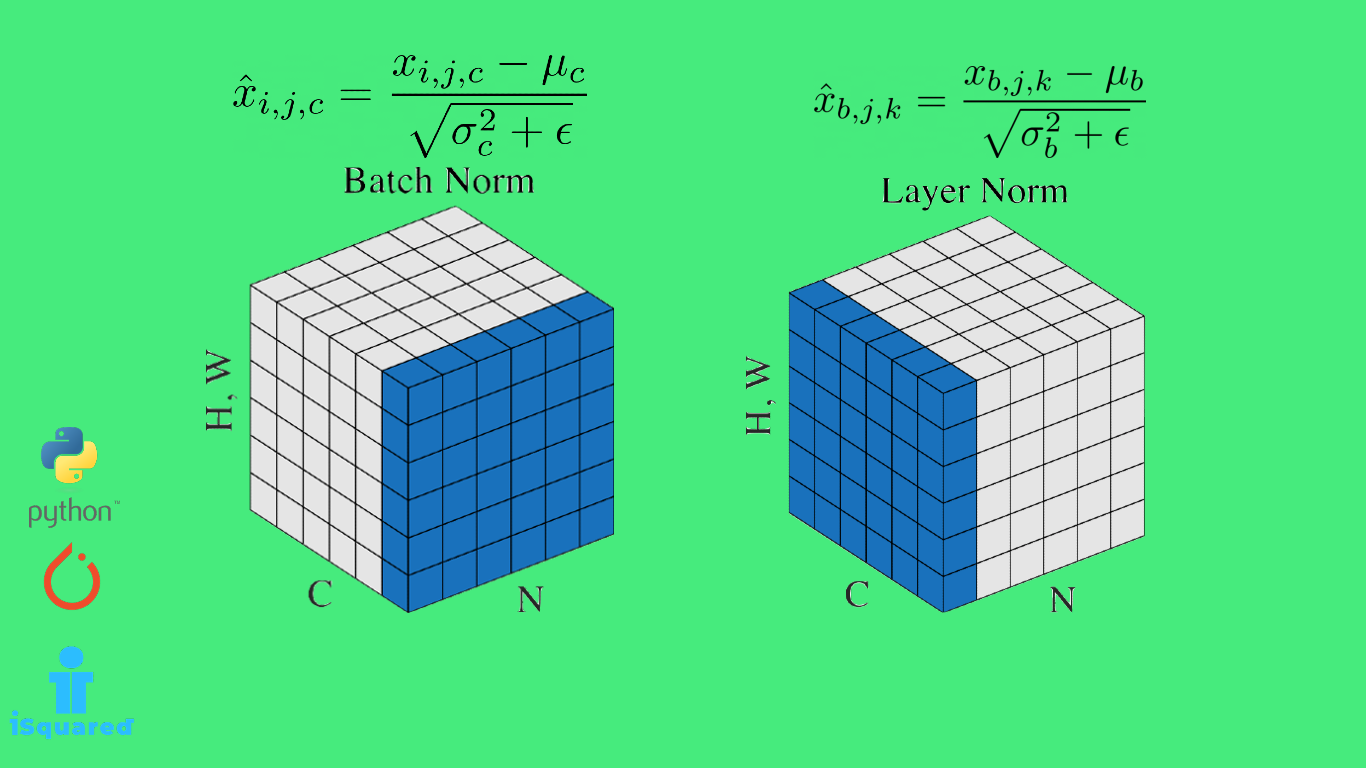

$$
y_i = \gamma \left( \frac{x_i - \mu_i}{\sqrt{\sigma_i^2 + \epsilon}} \right) + \beta
$$

`gamma` 和 `beta` 是可学习的缩放与偏移。实现时方差使用 `unbiased=False`，并加上 `eps`，这样小张量也不会因为除零而不稳定。


In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-5) -> None:
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, values: Tensor) -> Tensor:
        mean = values.mean(dim=-1, keepdim=True)
        variance = values.var(dim=-1, keepdim=True, unbiased=False)
        normalized = (values - mean) / torch.sqrt(variance + self.eps)
        return self.gamma * normalized + self.beta




## 4. FFN：每个位置再过一次小 MLP

attention 负责把不同位置的信息混合起来；Position-wise Feed-Forward Network 则对每个位置单独做一次非线性变换：

$$
\operatorname{FFN}(x)=W_2\,\operatorname{ReLU}(W_1x+b_1)+b_2
$$

中间层先扩到 `d_ff`，最后再投影回 `d_model`，这样才可以和残差连接相加。Dropout 放在中间是为了减少过拟合。


In [ ]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float) -> None:
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, values: Tensor) -> Tensor:
        return self.linear2(self.dropout(torch.relu(self.linear1(values))))

## 5. Multi-Head Attention：到底是哪两个向量在点积？

这一步是我当时最容易迷路的地方。输入先分别通过三个线性层得到 `Q`、`K`、`V`：

$$
Q=XW_Q,\qquad K=XW_K,\qquad V=XW_V
$$

每个 head 中，一个 query 会和所有 key 做点积，得到一个 `query_len × key_len` 的分数矩阵；Softmax 后再用这些权重加权 value：

$$
\operatorname{Attention}(Q,K,V)=
\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

形状变化可以这样记：

```text
(batch, time, d_model)
  -> (batch, heads, time, d_head)
  -> (batch, heads, query_time, key_time)
  -> (batch, time, d_model)
```

`matmul` 只在最后两维做矩阵乘法，前面的 `batch` 和 `heads` 只是并行批次。


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.0) -> None:
        super().__init__()
        if d_model <= 0 or n_heads <= 0 or d_model % n_heads != 0:
            raise ValueError(f'd_model ({d_model}) must be positive and divisible by n_heads ({n_heads})')
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_combine = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _validate_inputs(self, query: Tensor, key: Tensor, value: Tensor) -> None:
        for name, tensor in {'query': query, 'key': key, 'value': value}.items():
            if tensor.dim() != 3:
                raise ValueError(f'{name} must be three-dimensional (batch, sequence, features)')
            if tensor.size(-1) != self.d_model:
                raise ValueError(f'{name} feature dimension must equal d_model ({self.d_model})')
        if query.size(0) != key.size(0) or key.size(0) != value.size(0):
            raise ValueError('query, key, and value must have the same batch size')
        if key.size(1) != value.size(1):
            raise ValueError('key and value must have the same sequence length')

    def _expand_mask(self, mask: Tensor, scores: Tensor) -> Tensor:
        if mask.dtype != torch.bool:
            raise ValueError('attention mask must use torch.bool dtype')
        if mask.dim() == 2:
            mask = mask.unsqueeze(0).unsqueeze(0)
        elif mask.dim() == 3:
            mask = mask.unsqueeze(1)
        elif mask.dim() != 4:
            raise ValueError('attention mask must have two, three, or four dimensions')
        try:
            return torch.broadcast_to(mask.to(device=scores.device), scores.shape)
        except RuntimeError as error:
            raise ValueError('attention mask must broadcast to attention score shape') from error

    def forward(self, query: Tensor, key: Tensor, value: Tensor, mask: Tensor | None = None) -> Tensor:
        self._validate_inputs(query, key, value)
        batch_size, query_length, _ = query.shape
        key_length = key.size(1)

        def split_heads(projection: Tensor, sequence_length: int) -> Tensor:
            return projection.view(batch_size, sequence_length, self.n_heads, self.head_dim).transpose(1, 2)

        queries = split_heads(self.w_q(query), query_length)
        keys = split_heads(self.w_k(key), key_length)
        values = split_heads(self.w_v(value), key_length)
        scores = torch.matmul(queries, keys.transpose(-2, -1)) / math.sqrt(self.head_dim)

        expanded_mask = None
        if mask is not None:
            expanded_mask = self._expand_mask(mask, scores)
            # 原错误：score = score.masked_fill(mask == 0, 1e9)
            # 问题：正数让被遮挡位置在 softmax 后占主导。
            # 修正：填入当前 dtype 的极小值，使被遮挡位置权重接近零。
            scores = scores.masked_fill(~expanded_mask, torch.finfo(scores.dtype).min)

        weights = torch.softmax(scores, dim=-1)
        if expanded_mask is not None:
            weights = weights.masked_fill(~expanded_mask, 0.0)
        attended = torch.matmul(self.dropout(weights), values)
        attended = attended.transpose(1, 2).contiguous().view(batch_size, query_length, self.d_model)
        return self.w_combine(attended)

### 我当时写错的第一处：mask 的填充值

原来我把被遮挡的位置填成正的 `1e9`。这不是“很大负数”，而是一个巨大的正数，所以 Softmax 会反过来偏向这些本来应该被忽略的位置。修正版把原写法、问题和改法留在上面的代码注释里。

另一个容易被忽略的细节是：`q` 的序列长度和 `k/v` 的序列长度不一定相同，尤其是 cross-attention；所以代码不能把它们都写死成同一个 `time`。


In [ ]:
# 先用一个大一点的输入，只验证多头拆分后又回到 d_model。
X = torch.randn(128, 64, d_model)
attention = MultiHeadAttention(d_model=d_model, n_heads=n_heads)
attention_output = attention(X, X, X)
assert attention_output.shape == X.shape


运行这一格时，最重要的不是打印出一大串数字，而是确认最后一维仍然是 512。到这里，Embedding、位置编码和 attention 还是几个独立零件；接下来才把它们装成 Encoder/Decoder 的层。


## 6. Encoder Layer：attention 后面为什么还有两层？

一个 Encoder layer 的数据流是：

```text
输入
  -> Multi-Head Self-Attention
  -> 残差 + LayerNorm
  -> Position-wise FFN
  -> 残差 + LayerNorm
```

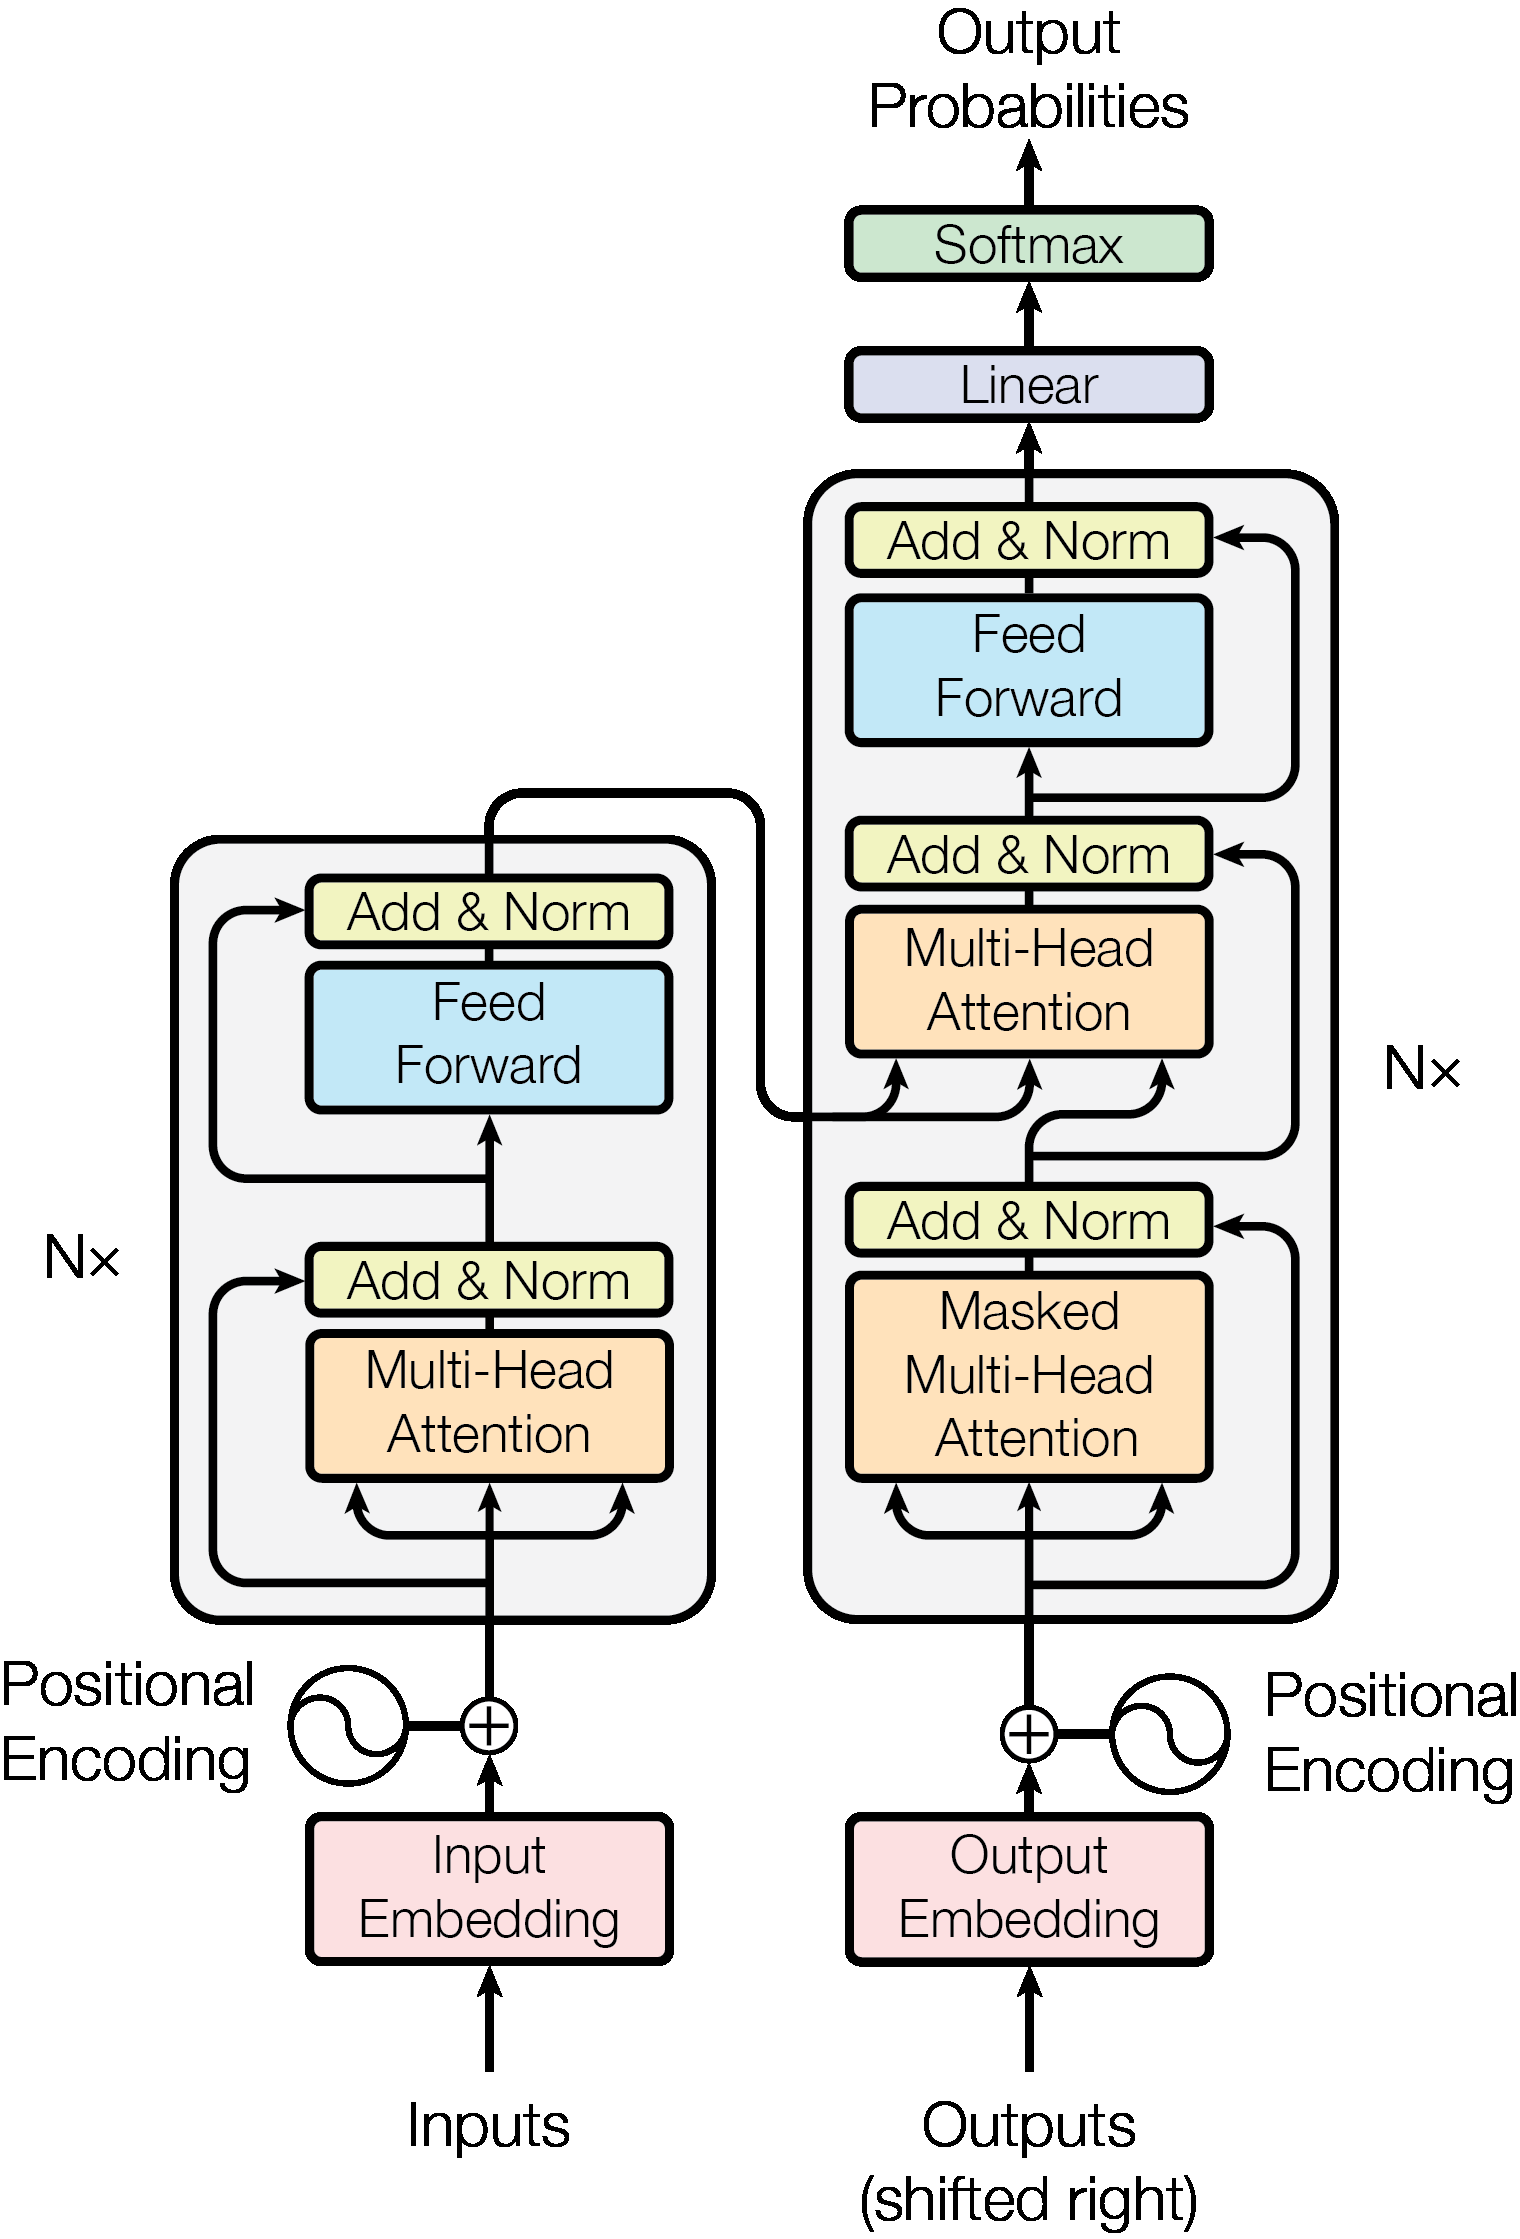

Encoder 只在源序列内部做 self-attention。残差连接让输入信号可以直接往后传，LayerNorm 则把每一层的数值尺度稳住。


看图写代码

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float) -> None:
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

    def forward(self, values: Tensor, src_mask: Tensor | None = None) -> Tensor:
        values = self.norm1(values + self.dropout1(self.self_attention(values, values, values, src_mask)))
        return self.norm2(values + self.dropout2(self.feed_forward(values)))




## 7. Decoder Layer：多出来的 cross-attention

Decoder 先做 masked self-attention，不能偷看目标序列未来的位置。然后它还要读取 Encoder 的输出：

- `Q` 来自 Decoder 当前状态；
- `K`、`V` 来自 Encoder 输出；
- `cross_mask` 屏蔽源序列中的 padding。

这就是经典 Encoder-Decoder Transformer 里的 cross-attention。它不是多余的一层，而是 Decoder 把源句子信息接回来的地方。


In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float) -> None:
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

    def forward(self, target_values: Tensor, encoder_output: Tensor | None, target_mask: Tensor | None = None, cross_mask: Tensor | None = None) -> Tensor:
        values = self.norm1(target_values + self.dropout1(
            self.self_attention(target_values, target_values, target_values, target_mask)
        ))
        # 原错误：if enc_output is None:
        # 问题：正常存在 encoder output 时跳过了交叉注意力。
        # 修正：仅在 encoder output 存在时执行交叉注意力。
        if encoder_output is not None:
            values = self.norm2(values + self.dropout2(
                self.cross_attention(values, encoder_output, encoder_output, cross_mask)
            ))
        return self.norm3(values + self.dropout3(self.feed_forward(values)))




### 我当时写错的第二处：cross-attention 条件写反

原代码写成了 `if enc_output is None`。这样正常有 Encoder 输出时反而跳过 cross-attention，空值时却尝试读取它。修正版保留了原错误注释，并改成“只有 `encoder_output` 存在时才执行”。


## 8. 把 Encoder、Decoder 组合起来

到这里，每一层已经准备好了。Encoder 和 Decoder 只是把对应的 embedding 和 layer 叠起来：

```text
source tokens -> source embedding -> Encoder layers -> encoder output
target tokens -> target embedding -> Decoder layers -> vocabulary logits
```

最后的线性层把 `d_model` 映射回目标词表大小，得到每个目标位置的 logits。


In [ ]:
class Encoder(nn.Module):
    def __init__(self, n_layers: int, d_model: int, n_heads: int, d_ff: int, vocab_size: int, max_len: int, padding_idx: int, dropout: float) -> None:
        super().__init__()
        self.embedding = TransformerEmbedding(vocab_size, d_model, max_len, padding_idx, dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, tokens: Tensor, src_mask: Tensor | None) -> Tensor:
        values = self.embedding(tokens)
        for layer in self.layers:
            values = layer(values, src_mask)
        return values


class Decoder(nn.Module):
    def __init__(self, n_layers: int, d_model: int, n_heads: int, d_ff: int, vocab_size: int, max_len: int, padding_idx: int, dropout: float) -> None:
        super().__init__()
        self.embedding = TransformerEmbedding(vocab_size, d_model, max_len, padding_idx, dropout)
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.output_projection = nn.Linear(d_model, vocab_size)

    def forward(self, tokens: Tensor, encoder_output: Tensor, target_mask: Tensor | None, cross_mask: Tensor | None) -> Tensor:
        values = self.embedding(tokens)
        for layer in self.layers:
            values = layer(values, encoder_output, target_mask, cross_mask)
        return self.output_projection(values)




## 9. Transformer 外层：mask 在哪里构造？

外层模块负责把 token id 变成三类 mask：

1. `src_mask`：Encoder 不看 source padding。
2. `target_mask`：Decoder 同时不看 target padding 和未来位置。
3. `cross_mask`：Decoder cross-attention 不读取 source padding。

### 我当时写错的第三处：默认漏掉 source padding mask

原来的逻辑只有在调用者传入 mask 时才重新构造 source mask；默认调用时就会把 source padding 放进 Encoder self-attention。修正版在 `src_mask is None` 时自动根据 token 构造它，原错误和修正也保留在代码注释中。


In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size: int, tgt_vocab_size: int, src_pad_idx: int, tgt_pad_idx: int, d_model: int, n_heads: int, d_ff: int, n_layers: int, max_len: int, dropout: float = 0.0) -> None:
        super().__init__()
        if n_layers <= 0:
            raise ValueError('n_layers must be positive')
        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, src_vocab_size, max_len, src_pad_idx, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, tgt_vocab_size, max_len, tgt_pad_idx, dropout)

    @staticmethod
    def make_padding_mask(query_tokens: Tensor, key_tokens: Tensor, query_pad_idx: int, key_pad_idx: int) -> Tensor:
        _require_token_matrix(query_tokens, 'query_tokens')
        _require_token_matrix(key_tokens, 'key_tokens')
        if query_tokens.size(0) != key_tokens.size(0):
            raise ValueError('query_tokens and key_tokens must have the same batch size')
        query_valid = query_tokens.ne(query_pad_idx).unsqueeze(1).unsqueeze(3)
        key_valid = key_tokens.ne(key_pad_idx).unsqueeze(1).unsqueeze(2)
        return query_valid & key_valid

    @staticmethod
    def make_causal_mask(length: int, device: torch.device) -> Tensor:
        if length <= 0:
            raise ValueError('length must be positive')
        return torch.tril(torch.ones(length, length, dtype=torch.bool, device=device))

    def forward(self, src_tokens: Tensor, tgt_tokens: Tensor, src_mask: Tensor | None = None) -> Tensor:
        _require_token_matrix(src_tokens, 'src_tokens')
        _require_token_matrix(tgt_tokens, 'tgt_tokens')
        if src_tokens.size(0) != tgt_tokens.size(0):
            raise ValueError('src_tokens and tgt_tokens must have the same batch size')
        # 原错误：只在 src_pad_mask 非空时才构造源序列 mask。
        # 问题：默认调用会忽略源序列 padding。
        # 修正：未显式传入 src_mask 时根据 token 自动构造。
        if src_mask is None:
            src_mask = self.make_padding_mask(src_tokens, src_tokens, self.src_pad_idx, self.src_pad_idx)
        target_padding_mask = self.make_padding_mask(tgt_tokens, tgt_tokens, self.tgt_pad_idx, self.tgt_pad_idx)
        causal_mask = self.make_causal_mask(tgt_tokens.size(1), tgt_tokens.device)
        target_mask = target_padding_mask & causal_mask
        cross_mask = self.make_padding_mask(tgt_tokens, src_tokens, self.tgt_pad_idx, self.src_pad_idx)
        encoder_output = self.encoder(src_tokens, src_mask)
        return self.decoder(tgt_tokens, encoder_output, target_mask, cross_mask)

## 10. 原始练习留下的 `tensor_src.pt` 和 `tensor_trg.pt`

原 Notebook 最后读取过两份本地 token 数据：`tensor_src.pt` 保存 source 序列，`tensor_trg.pt` 保存与之配对的 target 序列。它们分别约 38 KB 和 40 KB，都是 `torch.int64` 的整数 token id，不是模型参数，也不是训练缓存；形状分别是 `(128, 36)` 和 `(128, 38)`，原始数据使用 `1` 作为 padding id。

这次把两份小文件都放在 Notebook 同一目录中，为了兼容从 Notebook 目录、仓库根目录或 `lab-notebook-sharing` 根目录启动 Jupyter，下面按相对路径依次查找它们。


In [ ]:
from pathlib import Path


def find_tensor_path(filename: str) -> Path:
    candidates = (
        Path(filename),
        Path('06-nlp/wanglei') / filename,
        Path('lab-notebook-sharing/06-nlp/wanglei') / filename,
    )
    path = next((candidate for candidate in candidates if candidate.exists()), None)
    if path is None:
        raise FileNotFoundError(f'无法找到随 Notebook 提供的 {filename}')
    return path


src_path = find_tensor_path('tensor_src.pt')
tgt_path = find_tensor_path('tensor_trg.pt')
src_dataset = torch.load(src_path, map_location='cpu', weights_only=True)
tgt_dataset = torch.load(tgt_path, map_location='cpu', weights_only=True)
assert isinstance(src_dataset, Tensor) and isinstance(tgt_dataset, Tensor)
assert src_dataset.dim() == 2 and tgt_dataset.dim() == 2
assert src_dataset.dtype == torch.long and tgt_dataset.dtype == torch.long
assert src_dataset.size(0) == tgt_dataset.size(0)
print('tensor_src.pt:', tuple(src_dataset.shape), src_dataset.dtype)
print('tensor_trg.pt:', tuple(tgt_dataset.shape), tgt_dataset.dtype)


## 11. 用这对真实 source/target token 走一遍完整前向

现在 source 和 target 都来自原始练习留下的文件，并且取的是同一个 batch 中的第一对序列。这里的 target 只是 Decoder 的输入示例；模型没有训练，所以 logits 还不是有意义的翻译结果。


In [ ]:
src_tokens = src_dataset[:1]
tgt_tokens = tgt_dataset[:1]

model = Transformer(
    src_vocab_size=6000,
    tgt_vocab_size=8000,
    src_pad_idx=1,
    tgt_pad_idx=1,
    d_model=8,
    n_heads=2,
    d_ff=16,
    n_layers=1,
    max_len=max(src_tokens.size(1), tgt_tokens.size(1)),
    dropout=0.0,
).eval()

src_mask = model.make_padding_mask(src_tokens, src_tokens, 1, 1)
causal_mask = model.make_causal_mask(tgt_tokens.size(1), tgt_tokens.device)
with torch.no_grad():
    logits = model(src_tokens, tgt_tokens)

assert src_tokens.shape == (1, 36)
assert tgt_tokens.shape == (1, 38)
assert src_mask.shape == (1, 1, 36, 36)
assert causal_mask.shape == (38, 38)
assert logits.shape == (1, 38, 8000)
assert torch.isfinite(logits).all()


## 12. 回头看：这次手写真正要记住什么？

- `QK^T` 的最后两维决定了注意力分数矩阵的形状。
- 多头只是把 `d_model` 拆到不同子空间，最后还要拼回来。
- Padding mask 和 causal mask 的语义要统一：这里 `True` 表示可见。
- Encoder 的输出存在时，Decoder 才能做 cross-attention。
- mask 不能把某个 query 的所有 key 都屏蔽，否则 Softmax 可能出现 NaN。

这份实现适合用来理解数据流，不是一个完整的翻译训练项目。下一步如果要做下游任务，需要补 tokenizer、数据集、loss、优化器和评估指标。


## 13. 参考资料

- Vaswani et al., [Attention Is All You Need](https://arxiv.org/abs/1706.03762)
- [Transformer 全面指南](https://luxiangdong.com/2023/09/10/trans/)
- [李沐 Transformer 论文逐段精读（原笔记留下的 B 站线索，链接未核验）](https://www.bilibili.com/video/BV1pu411o7BE/)

原始视频现在无法确认；如果链接失效，可以在 B 站搜索“手写 Transformer”或“Transformer 论文精读”。

本 Notebook 的叙事顺序来自我之前的手写练习；代码中的三处错误注释对应当时实际出现过的实现问题。
